<a href="https://colab.research.google.com/github/Pratyush-Stha/MachineLearningLab/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.spatial.distance import minkowski
# Rewritten with the help of an AI coding assistant.


In [5]:
def get_df_dimensions(frame):
    '''Return (n_rows, n_cols) for a DataFrame.'''
    return frame.shape


def list_columns(frame):
    return frame.columns.tolist()


def column_dtypes(frame):
    return frame.dtypes


def count_nulls(frame):
    return frame.isna().sum()


def count_distinct(frame):
    return frame.nunique()


def numeric_columns(frame):
    return frame.select_dtypes(include="number").columns.tolist()


def non_numeric_columns(frame):
    return frame.select_dtypes(exclude="number").columns.tolist()


def memory_footprint_mb(frame):
    total_bytes = frame.memory_usage(deep=True).sum()
    return total_bytes / (1024 ** 2)


def build_summary_table(frame):
    return pd.DataFrame({
        "Data Type": frame.dtypes,
        "Missing Values": frame.isna().sum(),
        "Unique Values": frame.nunique(),
    })


def ordinal_encode(frame, columns):
    '''Encode categorical columns as integer codes using pd.factorize,
    sorting categories alphabetically for reproducible mappings.'''
    encoded = frame.copy()
    code_maps = {}

    for col in columns:
        sorted_categories = np.sort(encoded[col].dropna().unique())
        lookup = {category: idx for idx, category in enumerate(sorted_categories)}
        encoded[col] = encoded[col].map(lookup)
        code_maps[col] = lookup

    return encoded, code_maps


def dummy_encode(frame, columns, drop_first=False):
    '''One-hot encode the given columns by building indicator columns
    manually (rather than delegating straight to pd.get_dummies).'''
    encoded = frame.copy()

    for col in columns:
        categories = sorted(encoded[col].dropna().unique())
        if drop_first and categories:
            categories = categories[1:]
        for category in categories:
            new_col_name = f"{col}_{category}"
            encoded[new_col_name] = (encoded[col] == category).astype(int)
        encoded = encoded.drop(columns=[col])

    return encoded


def shape_info(frame):
    n_rows, n_cols = frame.shape
    return {"Rows": n_rows, "Features": n_cols}


def compare_shapes(before, after):
    return {
        "Original Features": before.shape[1],
        "Encoded Features": after.shape[1],
        "Feature Increase": after.shape[1] - before.shape[1],
    }


def lp_distance(vec_a, vec_b, p=2):
    '''Minkowski / Lp distance between two vectors, computed via
    numpy's built-in norm rather than a manual reduction.'''
    vec_a = np.asarray(vec_a, dtype=float)
    vec_b = np.asarray(vec_b, dtype=float)

    if vec_a.shape != vec_b.shape:
        raise ValueError("Vectors must have matching shapes.")

    return np.linalg.norm(vec_a - vec_b, ord=p)


def lp_distance_sweep(vec_a, vec_b, p_start=1, p_stop=10):
    orders = np.arange(p_start, p_stop + 1)
    distances = [lp_distance(vec_a, vec_b, order) for order in orders]
    return orders, distances


def inner_product(vec_a, vec_b):
    vec_a = np.asarray(vec_a, dtype=float)
    vec_b = np.asarray(vec_b, dtype=float)

    if vec_a.shape != vec_b.shape:
        raise ValueError("Vectors must have matching shapes.")

    return vec_a @ vec_b


def l2_norm(vec):
    vec = np.asarray(vec, dtype=float)
    return np.sqrt(vec @ vec)


def compute_mean(values):
    values = np.asarray(values, dtype=float)
    return values.sum() / values.size


def compute_variance(values):
    '''Population variance using the E[x^2] - (E[x])^2 identity.'''
    values = np.asarray(values, dtype=float)
    return (values ** 2).mean() - compute_mean(values) ** 2


def compute_std(values):
    return np.sqrt(compute_variance(values))


def draw_histogram(data, label, bins=20):
    plt.figure(figsize=(8, 5))

    plt.hist(
        data,
        bins=bins,
        edgecolor="black",
    )

    plt.title(f"Histogram of {label}")
    plt.xlabel(label)
    plt.ylabel("Frequency")
    plt.grid(True, alpha=0.3)

    plt.show()


def point_distance(p, q):
    return np.sqrt(np.sum((p - q) ** 2))


def nearest_centroid_labels(points, centroids):
    '''Vectorised assignment of each point to its closest centroid,
    using broadcasting instead of an explicit Python loop over points.'''
    # shape: (n_points, n_centroids)
    diffs = points[:, np.newaxis, :] - centroids[np.newaxis, :, :]
    sq_dists = np.sum(diffs ** 2, axis=2)
    return np.argmin(sq_dists, axis=1)


def recompute_centroids(points, labels, k):
    new_centroids = []

    for cluster_id in range(k):
        members = points[labels == cluster_id]

        if members.size == 0:
            new_centroids.append(points[np.random.randint(len(points))])
        else:
            new_centroids.append(members.mean(axis=0))

    return np.array(new_centroids)


def lloyd_clustering(points, k, max_iter=100, tol=1e-4):
    '''K-means clustering via Lloyd's algorithm.'''
    points = np.asarray(points, dtype=float)

    start_idx = np.random.choice(len(points), k, replace=False)
    centroids = points[start_idx]

    for _ in range(max_iter):
        labels = nearest_centroid_labels(points, centroids)
        updated_centroids = recompute_centroids(points, labels, k)

        if np.all(np.abs(updated_centroids - centroids) < tol):
            centroids = updated_centroids
            break

        centroids = updated_centroids

    return labels, centroids

In [6]:
df = pd.read_csv("marketing_campaign.csv")

In [7]:
n_rows, n_cols = get_df_dimensions(df)

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows               : {n_rows}")
print(f"Columns            : {n_cols}")
print(f"Memory Usage (MB)  : {memory_footprint_mb(df):.2f}")

print("\nFeature Names:")
print(list_columns(df))

print("\nNumerical Features:")
print(numeric_columns(df))

print("\nCategorical Features:")
print(non_numeric_columns(df))

print("\nData Types:")
print(column_dtypes(df))

print("\nMissing Values:")
print(count_nulls(df))

print("\nUnique Values:")
print(count_distinct(df))

print("\nFeature Summary:")
display(build_summary_table(df))

DATASET OVERVIEW
Rows               : 2240
Columns            : 29
Memory Usage (MB)  : 0.81

Feature Names:
['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Numerical Features:
['ID', 'Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response']

Categorical Featu

,Data Type,Missing Values,Unique Values
ID,int64,0,2240
Year_Birth,int64,0,59
Education,object,0,5
Marital_Status,object,0,8
Income,float64,24,1974
Kidhome,int64,0,3
Teenhome,int64,0,3
Dt_Customer,object,0,663
Recency,int64,0,100
MntWines,int64,0,776


In [8]:
cols_to_encode = ["Education", "Marital_Status"]

encoded_df, code_maps = ordinal_encode(df, cols_to_encode)

print("=" * 60)
print("ORDINAL ENCODING")
print("=" * 60)

for col in cols_to_encode:
    print(f"\n{col} Mapping:")
    for category, code_value in code_maps[col].items():
        print(f"{category:<20} -> {code_value}")

print("\nEncoded Data Sample:")
display(encoded_df[cols_to_encode].head())

ORDINAL ENCODING

Education Mapping:
2n Cycle             -> 0
Basic                -> 1
Graduation           -> 2
Master               -> 3
PhD                  -> 4

Marital_Status Mapping:
Absurd               -> 0
Alone                -> 1
Divorced             -> 2
Married              -> 3
Single               -> 4
Together             -> 5
Widow                -> 6
YOLO                 -> 7

Encoded Data Sample:


,Education,Marital_Status
0,2,4
1,2,4
2,2,5
3,2,5
4,4,3


In [9]:
cols_to_dummy = ["Education", "Marital_Status"]

dummy_df = dummy_encode(df, cols_to_dummy)

print("=" * 60)
print("ONE-HOT ENCODING")
print("=" * 60)

print(f"Original Shape : {df.shape}")
print(f"Encoded Shape  : {dummy_df.shape}")

print("\nNew Columns:")
added_cols = [c for c in dummy_df.columns if c not in df.columns]
print(added_cols)

print("\nEncoded Data Sample:")
display(dummy_df.head())

ONE-HOT ENCODING
Original Shape : (2240, 29)
Encoded Shape  : (2240, 40)

New Columns:
['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Absurd', 'Marital_Status_Alone', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Marital_Status_YOLO']

Encoded Data Sample:


,ID,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,Education_Master,Education_PhD,Marital_Status_Absurd,Marital_Status_Alone,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Marital_Status_YOLO
0,5524,1957,58138.0,0,0,4/9/2012,58,635,88,546,...,0,0,0,0,0,0,1,0,0,0
1,2174,1954,46344.0,1,1,8/3/2014,38,11,1,6,...,0,0,0,0,0,0,1,0,0,0
2,4141,1965,71613.0,0,0,21-08-2013,26,426,49,127,...,0,0,0,0,0,0,0,1,0,0
3,6182,1984,26646.0,1,0,10/2/2014,26,11,4,20,...,0,0,0,0,0,0,0,1,0,0
4,5324,1981,58293.0,1,0,19-01-2014,94,173,43,118,...,0,1,0,0,0,1,0,0,0,0


In [10]:
print("=" * 60)
print("FEATURE DIMENSIONALITY ANALYSIS")
print("=" * 60)

before_info = shape_info(df)
after_info = shape_info(dummy_df)

print(f"Original Dataset Shape : {df.shape}")
print(f"Encoded Dataset Shape  : {dummy_df.shape}")

print("\nOriginal Dataset")
print(f"Samples  : {before_info['Rows']}")
print(f"Features : {before_info['Features']}")

print("\nEncoded Dataset")
print(f"Samples  : {after_info['Rows']}")
print(f"Features : {after_info['Features']}")

shape_diff = compare_shapes(df, dummy_df)

print("\nDimensionality Change")
print(f"Original Features : {shape_diff['Original Features']}")
print(f"Encoded Features  : {shape_diff['Encoded Features']}")
print(f"Feature Increase  : {shape_diff['Feature Increase']}")

FEATURE DIMENSIONALITY ANALYSIS
Original Dataset Shape : (2240, 29)
Encoded Dataset Shape  : (2240, 40)

Original Dataset
Samples  : 2240
Features : 29

Encoded Dataset
Samples  : 2240
Features : 40

Dimensionality Change
Original Features : 29
Encoded Features  : 40
Feature Increase  : 11


In [11]:
numeric_df = df.select_dtypes(include="number")

vec_x = numeric_df.iloc[0].values
vec_y = numeric_df.iloc[1].values

print(lp_distance(vec_x, vec_y))

print(f"Manhattan Distance : {lp_distance(vec_x, vec_y, p=1):.4f}")
print(f"Euclidean Distance: {lp_distance(vec_x, vec_y, p=2):.4f}")

12290.371231171172
Manhattan Distance : 16781.0000
Euclidean Distance: 12290.3712


In [12]:
# Example: first two observations
dummy_numeric = dummy_df.select_dtypes(include="number")
vec_x = dummy_numeric.iloc[0].values.astype(float)
vec_y = dummy_numeric.iloc[1].values.astype(float)

orders, distances = lp_distance_sweep(vec_x, vec_y)

print("=" * 60)
print("MINKOWSKI DISTANCE ANALYSIS")
print("=" * 60)

for order, dist in zip(orders, distances):
    print(f"p = {order:<2} Distance = {dist:.4f}")

MINKOWSKI DISTANCE ANALYSIS
p = 1  Distance = 16781.0000
p = 2  Distance = 12290.3712
p = 3  Distance = 11884.3746
p = 4  Distance = 11813.1821
p = 5  Distance = 11798.3595
p = 6  Distance = 11795.0321
p = 7  Distance = 11794.2513
p = 8  Distance = 11794.0625
p = 9  Distance = 11794.0158
p = 10 Distance = 11794.0040


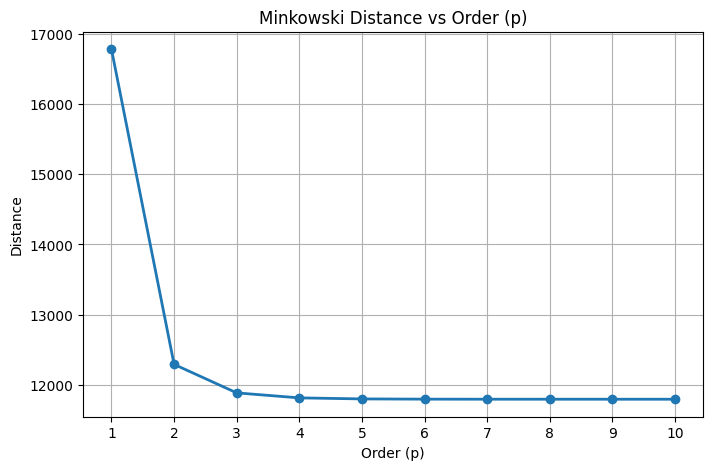

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    orders,
    distances,
    marker="o",
    linewidth=2,
    markersize=6,
)

plt.title("Minkowski Distance vs Order (p)")
plt.xlabel("Order (p)")
plt.ylabel("Distance")
plt.xticks(orders)
plt.grid(True)

plt.show()


In [14]:
dummy_numeric = dummy_df.select_dtypes(include="number")
vec_x = dummy_numeric.iloc[0].values.astype(float)
vec_y = dummy_numeric.iloc[1].values.astype(float)

print("=" * 70)
print("CUSTOM vs SCIPY MINKOWSKI DISTANCE")
print("=" * 70)

print(f"{'p':<5}{'Custom':>15}{'SciPy':>15}{'Difference':>15}")

for p in range(1, 11):
    mine = lp_distance(vec_x, vec_y, p)
    theirs = minkowski(vec_x, vec_y, p=p)

    print(f"{p:<5}{mine:>15.6f}{theirs:>15.6f}{abs(mine - theirs):>15.10f}")

CUSTOM vs SCIPY MINKOWSKI DISTANCE
p             Custom          SciPy     Difference
1       16781.000000   16781.000000   0.0000000000
2       12290.371231   12290.371231   0.0000000000
3       11884.374554   11884.374554   0.0000000000
4       11813.182057   11813.182057   0.0000000000
5       11798.359466   11798.359466   0.0000000000
6       11795.032150   11795.032150   0.0000000000
7       11794.251319   11794.251319   0.0000000000
8       11794.062465   11794.062465   0.0000000000
9       11794.015771   11794.015771   0.0000000000
10      11794.004032   11794.004032   0.0000000000


In [15]:
# Select two observations
dummy_numeric = dummy_df.select_dtypes(include="number")
vec_x = dummy_numeric.iloc[0].values.astype(float)
vec_y = dummy_numeric.iloc[1].values.astype(float)

print("=" * 70)
print("DOT PRODUCT COMPARISON")
print("=" * 70)

mine_dot = inner_product(vec_x, vec_y)
numpy_dot = np.dot(vec_x, vec_y)

print(f"Custom Dot Product : {mine_dot:.6f}")
print(f"NumPy Dot Product  : {numpy_dot:.6f}")
print(f"Difference         : {abs(mine_dot - numpy_dot):.10f}")

print("\n" + "=" * 70)
print("EUCLIDEAN NORM COMPARISON")
print("=" * 70)

mine_norm_x = l2_norm(vec_x)
numpy_norm_x = np.linalg.norm(vec_x)

mine_norm_y = l2_norm(vec_y)
numpy_norm_y = np.linalg.norm(vec_y)

print("Vector X")
print(f"Custom Norm : {mine_norm_x:.6f}")
print(f"NumPy Norm  : {numpy_norm_x:.6f}")
print(f"Difference  : {abs(mine_norm_x - numpy_norm_x):.10f}")

print("\nVector Y")
print(f"Custom Norm : {mine_norm_y:.6f}")
print(f"NumPy Norm  : {numpy_norm_y:.6f}")
print(f"Difference  : {abs(mine_norm_y - numpy_norm_y):.10f}")

DOT PRODUCT COMPARISON
Custom Dot Product : 2710194338.000000
NumPy Dot Product  : 2710194338.000000
Difference         : 0.0000000000

EUCLIDEAN NORM COMPARISON
Vector X
Custom Norm : 58439.108147
NumPy Norm  : 58439.108147
Difference  : 0.0000000000

Vector Y
Custom Norm : 46436.112456
NumPy Norm  : 46436.112456
Difference  : 0.0000000000


In [16]:
# Select any numeric feature (column)
feature = dummy_df["Income"].dropna().values.astype(float)

print("=" * 70)
print("MEAN, VARIANCE & STANDARD DEVIATION COMPARISON")
print("=" * 70)

# Mean
mine_mean = compute_mean(feature)
numpy_mean = np.mean(feature)

# Variance
mine_var = compute_variance(feature)
numpy_var = np.var(feature)

# Standard Deviation
mine_std = compute_std(feature)
numpy_std = np.std(feature)

print(f"{'Statistic':<20}{'Custom':>18}{'NumPy':>18}{'Difference':>18}")
print("-" * 74)

print(f"{'Mean':<20}{mine_mean:>18.6f}{numpy_mean:>18.6f}{abs(mine_mean - numpy_mean):>18.10f}")
print(f"{'Variance':<20}{mine_var:>18.6f}{numpy_var:>18.6f}{abs(mine_var - numpy_var):>18.10f}")
print(f"{'Std. Deviation':<20}{mine_std:>18.6f}{numpy_std:>18.6f}{abs(mine_std - numpy_std):>18.10f}")

MEAN, VARIANCE & STANDARD DEVIATION COMPARISON
Statistic                       Custom             NumPy        Difference
--------------------------------------------------------------------------
Mean                      52247.251354      52247.251354      0.0000000000
Variance              633397830.187273  633397830.187273      0.0000000000
Std. Deviation            25167.396174      25167.396174      0.0000000000


FEATURE DENSITY ANALYSIS
Feature Selected : Income
Number of Samples: 2216


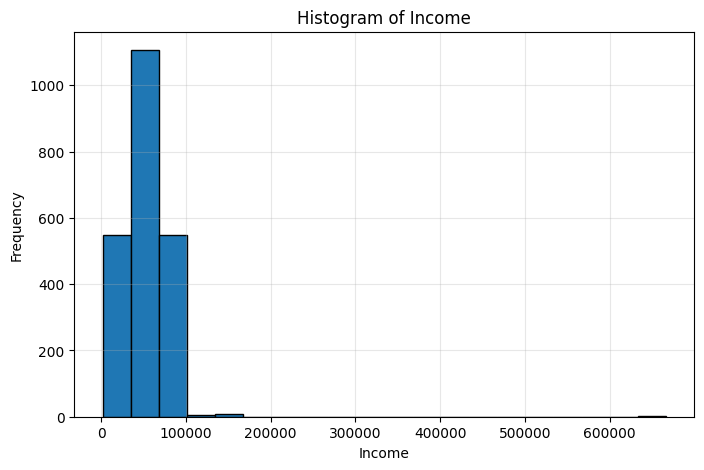

In [17]:
# Select a numerical feature
feature = dummy_df["Income"].dropna()

print("=" * 60)
print("FEATURE DENSITY ANALYSIS")
print("=" * 60)

print(f"Feature Selected : Income")
print(f"Number of Samples: {len(feature)}")

draw_histogram(feature, "Income")

In [18]:
X = dummy_df[["Income", "MntWines"]].dropna().values

k = 3

labels, centroids = lloyd_clustering(X, k)

print("=" * 60)
print("K-MEANS CLUSTERING")
print("=" * 60)

print(f"Number of Samples : {len(X)}")
print(f"Number of Clusters: {k}")

print("\nCluster Centers:")
print(centroids)

K-MEANS CLUSTERING
Number of Samples : 2216
Number of Clusters: 3

Cluster Centers:
[[5.43643587e+04 3.22766908e+02]
 [2.90555006e+04 3.41312102e+01]
 [7.95317612e+04 6.33563847e+02]]


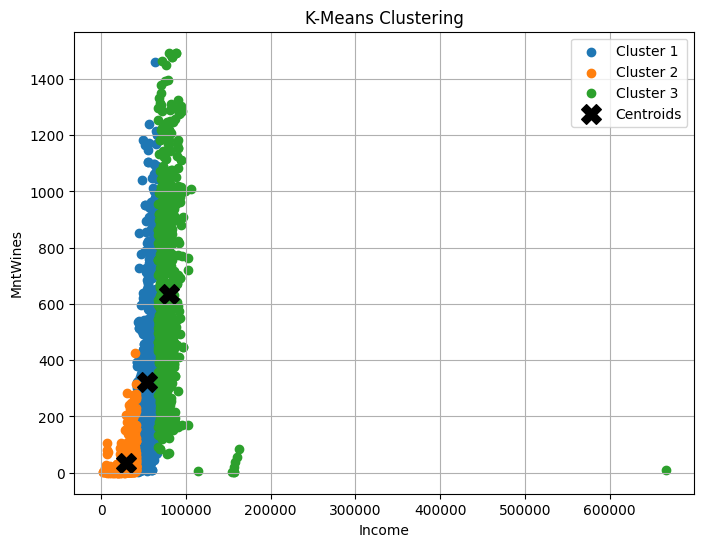

In [19]:
plt.figure(figsize=(8, 6))

for cluster_id in range(k):
    plt.scatter(
        X[labels == cluster_id, 0],
        X[labels == cluster_id, 1],
        label=f"Cluster {cluster_id + 1}",
    )

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=200,
    c="black",
    label="Centroids",
)

plt.title("K-Means Clustering")
plt.xlabel("Income")
plt.ylabel("MntWines")
plt.legend()
plt.grid(True)

plt.show()

In [20]:
print("=" * 70)
print("RUNNING UNIT TESTS")
print("=" * 70)

# -------------------------------
# Mean
# -------------------------------
assert compute_mean([1, 2, 3, 4, 5]) == 3.0

# -------------------------------
# Variance
# -------------------------------
assert np.isclose(compute_variance([1, 2, 3, 4, 5]), np.var([1, 2, 3, 4, 5]))

# -------------------------------
# Standard Deviation
# -------------------------------
assert np.isclose(compute_std([1, 2, 3, 4, 5]), np.std([1, 2, 3, 4, 5]))

# -------------------------------
# Dot Product
# -------------------------------
vec_x = np.array([1, 2, 3])
vec_y = np.array([4, 5, 6])

assert inner_product(vec_x, vec_y) == np.dot(vec_x, vec_y)

# -------------------------------
# Euclidean Norm
# -------------------------------
assert np.isclose(l2_norm(vec_x), np.linalg.norm(vec_x))

# -------------------------------
# Minkowski Distance
# -------------------------------
for p in range(1, 11):
    assert np.isclose(
        lp_distance(vec_x, vec_y, p),
        minkowski(vec_x, vec_y, p=p),
    )

# -------------------------------
# Ordinal Encoding
# -------------------------------
sample_df = pd.DataFrame({
    "Color": ["Red", "Blue", "Red", "Green"],
})

encoded_sample, sample_map = ordinal_encode(sample_df, ["Color"])

assert encoded_sample.shape == sample_df.shape
assert len(sample_map["Color"]) == 3

# -------------------------------
# One-Hot Encoding
# -------------------------------
dummy_sample = dummy_encode(sample_df, ["Color"])

assert dummy_sample.shape[1] == 3
assert "Color_Blue" in dummy_sample.columns
assert "Color_Green" in dummy_sample.columns
assert "Color_Red" in dummy_sample.columns

# -------------------------------
# K-Means
# -------------------------------
X_test = np.array([
    [1, 1],
    [1, 2],
    [9, 9],
    [9, 8],
])

test_labels, test_centroids = lloyd_clustering(X_test, k=2)

assert len(test_labels) == len(X_test)
assert test_centroids.shape == (2, 2)

print("\nAll unit tests passed successfully!")

RUNNING UNIT TESTS

All unit tests passed successfully!
